# 머신러닝 심화 I — 회귀 모델 비교 · 튜닝 · Stacking · SHAP

- 이 노트북은 `회귀예제_완성용(Lv3).ipynb`의 데이터 흐름을 확장합니다.
- **핵심 목표**
  + **train/test 분리 후** `X_train` 기준으로 파생변수를 생성하고, 동일 함수를 `X_test`에 적용합니다.
  +  10개 회귀 모델을 **과적합을 억제하는 탐색 공간**으로 `RandomizedSearchCV` 튜닝합니다.
  + 상위 모델을 `StackingRegressor`로 앙상블합니다.
  + **SHAP**으로 최종 모델의 변수 기여도를 해석합니다.
  + 테스트 데이터는 **마지막 최종 평가**에만 사용합니다.

- **사용 모델 10개**
요청하신 scikit-learn(및 주요 연동 라이브러리) 머신러닝 모델들의 공식 문서 참조 링크를 정리한 불릿 포인트 리스트입니다.
  + **Ridge Regression (릿지 회귀)** : [scikit-learn Ridge 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
  + **Lasso Regression (라쏘 회귀)** : [scikit-learn Lasso 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)
  + **Decision Tree (결정 트리)** : [scikit-learn DecisionTreeClassifier 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) & [scikit-learn DecisionTreeRegressor 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
  + **Random Forest (랜덤 포레스트)** : [scikit-learn RandomForestClassifier 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) & [scikit-learn RandomForestRegressor 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
  + **Gradient Boosting (그래디언트 부스팅)** : [scikit-learn GradientBoostingClassifier 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) & [scikit-learn GradientBoostingRegressor 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)
  +  **KNN (K-최근접 이웃)** : [scikit-learn KNeighborsClassifier 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) & [scikit-learn KNeighborsRegressor 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
  + **SVR (서포트 벡터 회귀)** : [scikit-learn SVR 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html)
  + **XGBoost (엑스지부스트)** : [XGBoost Scikit-Learn API 공식 문서](https://www.google.com/search?q=https://xgboost.readthedocs.io/en/stable/python/python_api.html%23module-xgboost.sklearn)
  + **LightGBM (라이트지비엠)** : [LightGBM Scikit-Learn API 공식 문서](https://www.google.com/search?q=https://lightgbm.readthedocs.io/en/stable/python_api.html%23scikit-learn-api)
  + **CatBoost (캣부스트)** : [CatBoost 고유 Scikit-Learn API 공식 문서](https://www.google.com/search?q=https://catboost.ai/en/docs/concepts/python-reference_catboostclassifier)

## 1. 환경 설정

In [2]:
!pip install xgboost lightgbm catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [1]:
# ==============================================================================
# [1] 개발 환경 및 패키지 권장 버전 안내
# ==============================================================================
# 권장 환경: scikit-learn==1.6.1, xgboost, lightgbm, catboost, shap
# 설치 예시: uv pip install scikit-learn==1.6.1 xgboost lightgbm catboost shap

import sys
import time
from pathlib import Path
import warnings

# ==============================================================================
# [2] OS 환경 확인 및 한글 폰트(나눔폰트) 설치 (리눅스/우분투 환경 대상)
# ==============================================================================
# macOS('darwin')가 아닌 리눅스/우분투 환경(예: Google Colab)일 때만 시스템 폰트를 설치합니다.
if sys.platform != 'darwin':
    # -qq 옵션과 2>/dev/null을 사용하여 설치 로그를 숨기고 조용히 설치합니다.
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    # 폰트 캐시를 갱신하여 시스템에 반영합니다.
    !fc-cache -fv 2>/dev/null
    # matplotlib의 구형 폰트 캐시를 삭제하여 새로 설치된 폰트를 인식하게 합니다.
    !rm -rf ~/.cache/matplotlib 2>/dev/null

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

ModuleNotFoundError: No module named 'catboost'

In [3]:
# ==============================================================================
# [3] 데이터 분석 및 머신러닝 라이브러리 임포트
# ==============================================================================
# 수치 연산 및 데이터프레임 제어
import numpy as np
import pandas as pd

# 시각화 패키지 및 폰트 매니저
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm  # 시스템에 설치된 폰트를 탐색하고 그래프 폰트로 등록해주는 매니저
import seaborn as sns

# 모델 해석 라이브러리 및 사이킷런 기초
import sklearn
import shap

# 전처리 및 파이프라인 구축을 위한 모듈
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 평가지표 및 검증/하이퍼파라미터 튜닝 모듈
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split

# 선형 모델 및 이웃 기반 모델
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor

# 트리 기반 및 서포트 벡터 머신 모델
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# 앙상블(Ensemble) 모델
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor

# 외부 부스팅 라이브러리 (Scikit-Learn API 기반 회귀 모델들)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# ==============================================================================
# [4] 기본 경고 및 난수(Seed) 설정
# ==============================================================================
# 분석 실행 시 발생하는 불필요한 경고 메시지를 숨깁니다.
warnings.filterwarnings('ignore')

# 모델 결과의 재현성을 위해 난수 시드를 고정합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ==============================================================================
# [5] 리눅스 및 macOS 경로의 한글 폰트(나눔폰트) 등록
# ==============================================================================
# 리눅스 우분투 및 macOS의 기본 폰트 경로를 탐색하여 나눔폰트를 matplotlib에 수동 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# ==============================================================================
# [6] Matplotlib 및 Seaborn 글로벌 시각화 설정
# ==============================================================================
# 마이너스 기호(-) 깨짐 방지 및 나눔바른고딕을 기본 폰트로 지정합니다.
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',  # 기본 폰트를 '나눔바른고딕'으로 설정
    'axes.unicode_minus': False,        # 축의 마이너스 기호(-)가 네모로 깨지는 현상 방지
    'figure.dpi': 110                   # 노트북 환경 등에서 선명하게 보이도록 그래프 해상도 설정
})

# Seaborn 테마에 기본 폰트 스타일과 마이너스 깨짐 방지 옵션을 적용합니다.
sns.set_theme(
    style='whitegrid',                  # 배경을 격자무늬(grid)가 있는 깔끔한 흰색으로 지정
    font='NanumBarunGothic',            # Seaborn 차트에 사용할 기본 폰트 지정
    rc={'axes.unicode_minus': False}    # 마이너스 기호 깨짐 방지 설정 적용
)

# ==============================================================================
# [7] 설정 완료 확인 및 버전 출력
# ==============================================================================
print('sklearn version:', sklearn.__version__)
print('환경 설정 완료')

sklearn version: 1.6.1
환경 설정 완료


## 2. 데이터 로드 및 변수 선택

Lv3 회귀 예제와 동일하게 Kaggle House Price `train.csv`를 사용합니다.
이 단계에서는 **원본 변수만** 선택하고, 파생변수는 아직 만들지 않습니다.


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# ==============================================================================
# [1] 데이터 파일 경로 설정 및 존재 여부 검증
# ==============================================================================
# 캐글 주택 가격 데이터셋(Kaggle House Price)이 저장된 기본 디렉토리 경로 지정
DATA_DIR = Path('/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/kaggle_house_price')

# 학습 데이터(train)와 평가 데이터(test)의 전체 파일 경로 생성
train_path = DATA_DIR / 'train.csv'
test_path = DATA_DIR / 'test.csv'

# 지정한 경로에 학습용/평가용 CSV 파일이 모두 존재하는지 확인 후 데이터 로드
if train_path.exists() and test_path.exists():
    house = pd.read_csv(train_path)          # 모델 학습 및 검증용 데이터셋
    kaggle_test = pd.read_csv(test_path)     # 캐글 제출 및 최종 평가용 데이터셋

    # 불러온 데이터프레임의 행(Row)과 열(Column) 크기 출력
    print('train.csv shape:', house.shape)
    print('test.csv shape :', kaggle_test.shape)

    # 데이터의 구성을 직관적으로 파악하기 위해 주요 컬럼(ID, 품질, 면적, 가격 등) 일부만 상위 5행 출력
    display(house.loc[:, ['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'SalePrice']].head())
else:
    # 경로가 잘못되었거나 파일이 없을 경우 디버깅을 위한 에러 메시지 출력
    print(f"Error: 지정된 경로에 파일이 존재하지 않습니다.\n확인한 경로: {DATA_DIR}")

# ==============================================================================
# [2] 분석 및 모델링에 사용할 특징(Feature)과 타겟(Target) 정의
# ==============================================================================
# 예측 모델의 입력값으로 사용할 기본 피처 리스트 (수치형 및 범주형 변수 포함)
base_features = [
    'OverallQual',   # 전반적인 자재 및 마감 품질 (수치형/예측에 중요)
    'GrLivArea',     # 지상 주거 면적 (SqFt 단위)
    'TotalBsmtSF',   # 지하실 총 면적
    'FullBath',      # 지상층 풀-바스룸 개수
    'HalfBath',      # 지상층 하프-바스룸 개수
    'BsmtFullBath',  # 지하실 풀-바스룸 개수
    'BsmtHalfBath',  # 지하실 하프-바스룸 개수
    'GarageCars',    # 차고 수용 가능 차량 수
    'YearBuilt',     # 원본 건축 연도
    'YrSold',        # 매매 연도
    'Neighborhood',  # Ames 시내 물리적 위치 (범주형)
    'HouseStyle',    # 주거 스타일/층수 (범주형)
    'ExterQual',     # 외재 품질 평가 (범주형)
    'CentralAir',    # 중앙 냉방 여부 (Y/N 범주형)
]

# 모델이 예측해야 하는 대상 타겟 변수 (주택 매매 가격)
target = 'SalePrice'

# ==============================================================================
# [3] 독립변수(X)와 종속변수(y) 분리 및 확인
# ==============================================================================
# 원본 데이터프레임에서 정의한 피처와 타겟만 추출하여 명시적 복사(copy)본 생성
X = house.loc[:, base_features].copy()
y = house.loc[:, target].copy()

# 분리된 입력 데이터(X)와 정답 레이블(y)의 차원 정보 출력
print('X shape:', X.shape)
print('y shape:', y.shape)

# 최종 선택된 입력 데이터프레임(X)의 상위 5개 데이터 확인
X.head()

train.csv shape: (1460, 81)
test.csv shape : (1459, 80)


,Id,OverallQual,GrLivArea,GarageCars,YearBuilt,SalePrice
0,1,7,1710,2,2003,208500
1,2,6,1262,2,1976,181500
2,3,7,1786,2,2001,223500
3,4,7,1717,3,1915,140000
4,5,8,2198,3,2000,250000


X shape: (1460, 14)
y shape: (1460,)


,OverallQual,GrLivArea,TotalBsmtSF,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,GarageCars,YearBuilt,YrSold,Neighborhood,HouseStyle,ExterQual,CentralAir
0,7,1710,856,2,1,1,0,2,2003,2008,CollgCr,2Story,Gd,Y
1,6,1262,1262,2,0,0,1,2,1976,2007,Veenker,1Story,TA,Y
2,7,1786,920,2,1,1,0,2,2001,2008,CollgCr,2Story,Gd,Y
3,7,1717,756,1,0,1,0,3,1915,2006,Crawfor,2Story,TA,Y
4,8,2198,1145,2,1,1,0,3,2000,2008,NoRidge,2Story,Gd,Y


## 3. train/test 분리 후 파생변수 생성

Lv3와 동일하게 **분리 먼저 → `X_train`에서 파생변수 생성 → 같은 함수를 `X_test`에 적용**합니다.

타깃(`SalePrice`)을 사용하지 않는 결정론적 파생변수만 추가합니다.


In [6]:
# ==============================================================================
# [1] 데이터셋 분할 (Train / Test Split)
# ==============================================================================
# 데이터 누수(Data Leakage) 방지를 위해 파생변수 생성 전 원본 데이터를 먼저 분할합니다.
# 전체 데이터의 20%를 모델 검증을 위한 테스트(Test)셋으로, 80%를 학습(Train)셋으로 활용합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# 데이터 분리 직후의 학습 및 테스트 데이터 차원(Shape) 확인
print('분리 직후 train:', X_train.shape)
print('분리 직후 test :', X_test.shape)


# ==============================================================================
# [2] 도메인 지식 기반 파생변수(Feature Engineering) 생성 함수 정의
# ==============================================================================
def add_house_features(df):
    """타깃(SalePrice) 변수를 참조하지 않는 순수 독립변수 기반 파생변수 생성 함수.

    - HouseAge   : 주택 매매 시점 기준의 건물 연식 (현재 연도 - 건축 연도)
    - TotalBath  : 지상/지하 전체 욕실 수 통합 (하프 바스룸은 0.5 가중치 부여)
    - AreaPerCar : 차고 1대 공간당 주거 면적 비율 (차고가 없는 0의 경우 NaN 처리하여 ZeroDivisionError 방지)
    """
    # 원본 데이터프레임의 손상을 막기 위한 명시적 카피 생성
    out = df.copy()

    # 1. 주택 연식 파생변수 생성
    out.loc[:, 'HouseAge'] = out.loc[:, 'YrSold'] - out.loc[:, 'YearBuilt']

    # 2. 총 욕실 수 종합 파생변수 생성 (풀바스 + 하프바스*0.5 + 지하풀바스 + 지하하프바스*0.5)
    out.loc[:, 'TotalBath'] = (
        out.loc[:, 'FullBath']
        + 0.5 * out.loc[:, 'HalfBath']
        + out.loc[:, 'BsmtFullBath']
        + 0.5 * out.loc[:, 'BsmtHalfBath']
    )

    # 3. 차고 수용력 대비 거주 면적 비율 생성 (0대인 주택은 np.nan으로 치환하여 계산 오류 예방)
    out.loc[:, 'AreaPerCar'] = out.loc[:, 'GrLivArea'] / out.loc[:, 'GarageCars'].replace(0, np.nan)

    return out


# ==============================================================================
# [3] 학습 및 테스트 데이터셋에 파생변수 일괄 적용
# ==============================================================================
# 1. 정의한 함수를 학습 데이터셋에 먼저 적용
X_train = add_house_features(X_train)

# 2. 동일한 변환 규칙을 테스트 데이터셋에도 그대로 적용 (Data Leakage 차단)
X_test = add_house_features(X_test)


# ==============================================================================
# [4] 데이터 타입별(수치형/범주형) 피처 그룹 재정의
# ==============================================================================
# 파생변수가 추가된 최종 수치형(Numeric) 피처 리스트
numeric_features = [
    'OverallQual', 'GrLivArea', 'TotalBsmtSF', 'FullBath', 'HalfBath',
    'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'YearBuilt', 'YrSold',
    'HouseAge', 'TotalBath', 'AreaPerCar',
]

# 원본의 범주형(Categorical) 피처 리스트
categorical_features = ['Neighborhood', 'HouseStyle', 'ExterQual', 'CentralAir']


# ==============================================================================
# [5] 최종 파생변수 반영 결과 확인
# ==============================================================================
# 3개의 파생변수 컬럼이 정상적으로 추가되었는지 차원(Shape) 변화 확인 (기존 14개 -> 17개)
print('파생변수 적용 후 train:', X_train.shape)
print('파생변수 적용 후 test :', X_test.shape)

# 파생변수가 결합된 최종 학습용 데이터프레임(X_train) 상위 5행 출력
X_train.head()

분리 직후 train: (1168, 14)
분리 직후 test : (292, 14)
파생변수 적용 후 train: (1168, 17)
파생변수 적용 후 test : (292, 17)


,OverallQual,GrLivArea,TotalBsmtSF,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,GarageCars,YearBuilt,YrSold,Neighborhood,HouseStyle,ExterQual,CentralAir,HouseAge,TotalBath,AreaPerCar
254,5,1314,1314,1,0,1,0,1,1957,2010,NAmes,1Story,TA,Y,53,2.0,1314.0
1066,6,1571,799,2,1,0,0,2,1993,2009,Gilbert,2Story,Gd,Y,16,2.5,785.5
638,5,796,796,1,0,0,0,0,1910,2008,Edwards,1Story,TA,Y,98,1.0,NaN
799,5,1768,731,1,1,1,0,1,1937,2007,SWISU,1.5Fin,TA,Y,70,2.5,1768.0
380,5,1691,1026,2,0,0,0,1,1924,2010,SWISU,1.5Fin,TA,Y,86,2.0,1691.0


## 4. 공통 Pipeline 전처리 (sklearn 1.6.1)

- 수치형: `SimpleImputer(strategy='median')` + `StandardScaler`
- 범주형: `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(sparse_output=False)`

> sklearn 1.6.1 기준 `sparse_output=False` 를 사용합니다. (`make_onehot` 헬퍼 불필요)


In [7]:
# ==============================================================================
# [1] 수치형 데이터 전처리 파이프라인 (Numerical Pipeline)
# ==============================================================================
# 수치형 피처들의 결측치 처리 및 스케일링을 차례대로 수행하는 파이프라인 정의
numeric_transformer = Pipeline([
    # 1. 결측치가 존재할 경우 해당 컬럼의 '중앙값(Median)'으로 대체합니다. (이상치에 강건함)
    ('imputer', SimpleImputer(strategy='median')),

    # 2. 데이터의 평균을 0, 표준편차를 1로 맞추는 표준화(Standardization)를 적용합니다.
    ('scaler', StandardScaler()),
])

# ==============================================================================
# [2] 범주형 데이터 전처리 파이프라인 (Categorical Pipeline)
# ==============================================================================
# 범주형 피처들의 결측치 처리 및 원-핫 인코딩을 차례대로 수행하는 파이프라인 정의
categorical_transformer = Pipeline([
    # 1. 결측치가 존재할 경우 해당 컬럼의 '최빈값(Most Frequent)'으로 대체합니다.
    ('imputer', SimpleImputer(strategy='most_frequent')),

    # 2. 범주형 텍스트 데이터를 0과 1로 이루어진 더미 변수로 변환합니다.
    # - handle_unknown='ignore': 학습 데이터에서 보지 못한 새로운 범주가 테스트 데이터에 등장해도 에러를 내지 않고 모두 0으로 처리합니다.
    # - sparse_output=False: sparse matrix(희소 행렬) 대신 일반적인 구조의 dense array(밀집 배열)를 반환하도록 설정합니다. (구 버전의 sparse=False와 동일)
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# ==============================================================================
# [3] 전처리 파이프라인 통합 (ColumnTransformer)
# ==============================================================================
# 데이터프레임의 컬럼 타입(수치형/범주형)에 맞춰 각각 지정된 파이프라인을 매핑하는 통합 전처리 변환기
preprocessor = ColumnTransformer([
    # ('이름', 적용할 변환기/파이프라인, 대상 피처 리스트)
    ('num', numeric_transformer, numeric_features),        # 수치형 변수 변환 적용
    ('cat', categorical_transformer, categorical_features),  # 범주형 변수 변환 적용
])

# ==============================================================================
# [4] 모델 검증을 위한 교차 검증(Cross Validation) 설정
# ==============================================================================
# 5개의 폴드(Fold)로 데이터를 나누어 모델 성능을 객관적으로 평가하기 위한 K-Fold 객체 생성
# - n_splits=5: 데이터를 5등분하여 4개는 학습, 1개는 검증용으로 순환하며 사용합니다.
# - shuffle=True: 데이터를 나누기 전 무작위로 섞어 특정 순서에 따른 편향(Bias)을 방지합니다.
# - random_state: 교차 검증 시 수행되는 데이터 셔플링 결과의 재현성을 위해 시드를 고정합니다.
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ==============================================================================
# [5] 설정 완료 확인
# ==============================================================================
print('공통 전처리와 5-Fold CV 준비 완료')

공통 전처리와 5-Fold CV 준비 완료


## 5. 10개 모델과 튜닝 공간 정의

각 모델의 탐색 범위는 **공식 문서의 regularization / tree complexity 파라미터**를 참고해 과적합을 줄이는 방향으로 설정했습니다.

| 모델 | 과적합 억제 포인트 (문서 기준) |
|------|-------------------------------|
| Ridge / Lasso | `alpha` ↑ → 규제 강화 |
| DecisionTree | `max_depth`, `min_samples_leaf`, `min_samples_split` 제한 |
| RandomForest | `max_depth` 상한, `min_samples_leaf`, `max_features` 축소 |
| GradientBoosting | 얕은 트리(`max_depth` 2~3), `subsample` < 1 |
| KNN | `n_neighbors` 증가 |
| SVR | 작은 `C` 값(규제 강화) |
| XGB / LGBM / CatBoost | `max_depth/depth` 제한, `reg_*`, `min_child_*`, `subsample` |


In [15]:
from scipy.stats import uniform, randint, loguniform

# ==============================================================================
# [1] RandomizedSearchCV 하이퍼파라미터 탐색 공간 정의
# ==============================================================================
# - 딕셔너리 구조: {'모델명': (기본_모델_객체, 하이퍼파라미터_탐색_분포_딕셔너리)}
# - 파라미터 접두사('model__'): 사이킷런 Pipeline 내에서 개별 모델 단에 적용하기 위해 사용합니다.
# - 모든 모델에 동일한 n_iter를 적용하여 "탐색 횟수" 기준의 공정성을 확보합니다.

model_spaces = {

    # --------------------------------------------------------------------------
    # 선형 회귀 계열 (Linear Models)
    # --------------------------------------------------------------------------
    'Ridge': (
        Ridge(),
        {
            'model__alpha': loguniform(1e-1, 3e2),             # 1~300 사이 로그스케일 탐색
        },
    ),

    'Lasso': (
        Lasso(max_iter=10000, random_state=RANDOM_STATE),
        {
            'model__alpha': loguniform(1e-3, 1e1),             # 0.001~10 사이 로그스케일 탐색
        },
    ),

    # --------------------------------------------------------------------------
    # 트리 계열 (Tree-based Model)
    # --------------------------------------------------------------------------
    'DecisionTree': (
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {
            'model__max_depth': randint(3, 11),                # 3~10
            'model__min_samples_leaf': randint(5, 21),         # 5~20
            'model__min_samples_split': randint(10, 41),       # 10~40
        },
    ),

    # --------------------------------------------------------------------------
    # 앙상블 배깅 계열 (Ensemble Bagging)
    # --------------------------------------------------------------------------
    'RandomForest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            'model__n_estimators': randint(100, 301),          # 100~300
            'model__max_depth': randint(5, 16),                # 5~15
            'model__min_samples_leaf': randint(2, 11),         # 2~10
            'model__min_samples_split': randint(5, 11),        # 5~10
            'model__max_features': ['sqrt', 0.5, 0.7],         # 카테고리형이라 리스트 유지
        },
    ),

    # --------------------------------------------------------------------------
    # 앙상블 부스팅 계열 (Ensemble Boosting - Scikit-Learn 내장)
    # --------------------------------------------------------------------------
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            'model__n_estimators': randint(100, 301),
            'model__learning_rate': loguniform(0.01, 0.2),
            'model__max_depth': randint(2, 6),                 # 2~5 (다른 트리 계열과 정렬)
            'model__subsample': uniform(0.6, 0.3),             # 0.6~0.9
            'model__min_samples_leaf': randint(5, 21),
        },
    ),

    # --------------------------------------------------------------------------
    # 거리/서포트 벡터 계열 (Distance/SVM Models)
    # --------------------------------------------------------------------------
    'KNN': (
        KNeighborsRegressor(),
        {
            'model__n_neighbors': randint(3, 31),              # 3~30
            'model__weights': ['uniform', 'distance'],         # 카테고리형이라 리스트 유지
        },
    ),

    'SVR': (
        SVR(),
        {
            'model__C': loguniform(1e-1, 1e2),                 # 0.1~100
            'model__epsilon': uniform(0.05, 0.25),             # 0.05~0.3
            'model__kernel': ['rbf'],                          # 카테고리형이라 리스트 유지
        },
    ),

    # --------------------------------------------------------------------------
    # 외부 고급 부스팅 계열 (Advanced Boosting Frameworks)
    # --------------------------------------------------------------------------
    'XGBoost': (
        XGBRegressor(
            random_state=RANDOM_STATE,
            objective='reg:squarederror',
            n_jobs=-1,
        ),
        {
            'model__n_estimators': randint(100, 301),
            'model__max_depth': randint(3, 6),                 # 3~5
            'model__learning_rate': loguniform(0.01, 0.2),
            'model__subsample': uniform(0.6, 0.3),
            'model__colsample_bytree': uniform(0.6, 0.3),
            'model__reg_alpha': loguniform(1e-3, 1.0),
            'model__reg_lambda': loguniform(1e-3, 1.0),
            'model__min_child_weight': randint(1, 6),
        },
    ),

    'LightGBM': (
        LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        {
            'model__n_estimators': randint(100, 301),
            'model__num_leaves': randint(7, 32),               # depth 3~5 근사 (2^depth - 1)
            'model__learning_rate': loguniform(0.01, 0.2),
            'model__min_child_samples': randint(10, 41),
            'model__subsample': uniform(0.6, 0.3),
            'model__colsample_bytree': uniform(0.6, 0.3),      # 다른 부스팅 모델과 통일 위해 추가
            'model__reg_alpha': loguniform(1e-3, 1.0),
            'model__reg_lambda': loguniform(1e-3, 1.0),
        },
    ),

    'CatBoost': (
        CatBoostRegressor(
            random_state=RANDOM_STATE,
            verbose=False,
            loss_function='RMSE',
            bootstrap_type='Bernoulli',                        # subsample 사용을 위해 필요
        ),
        {
            'model__iterations': randint(100, 301),
            'model__depth': randint(3, 6),                     # 3~5, 다른 트리 계열과 정렬
            'model__learning_rate': loguniform(0.01, 0.2),
            'model__subsample': uniform(0.6, 0.3),
            'model__rsm': uniform(0.6, 0.3),                   # colsample_bytree 대응 (컬럼 샘플링)
            'model__l2_leaf_reg': loguniform(1.0, 30.0),
        },
    ),
}

# ==============================================================================
# [2] 설정 결과 검증
# ==============================================================================
print('모델 개수:', len(model_spaces))

모델 개수: 10


## 6. 모델별 튜닝 및 교차검증 비교

각 모델은 `Pipeline(preprocessor + model)` 로 감싼 뒤 `RandomizedSearchCV`를 수행합니다.
평가 지표는 **RMSE**이며, train/validation gap으로 과적합을 함께 확인합니다.


In [18]:
from tqdm.auto import tqdm
import time

# ==============================================================================
# [1] 결과를 저장할 자료구조 및 공통 탐색 횟수(N_ITER) 정의
# ==============================================================================
search_objects = {}  # 모델 해석 및 재사용을 위해 최적화가 완료된 search 객체를 저장할 딕셔너리
rows = []            # 각 모델의 최적 성능 통계량을 행(Row) 단위로 누적할 리스트

# 각 모델당 확률 분포 공간에서 무작위로 샘플링하여 실험할 하이퍼파라미터 조합 총 횟수
N_ITER = 50

# ==============================================================================
# [2] tqdm 진행 바를 동반한 10개 알고리즘 순차 루프 실행
# ==============================================================================
# desc 파라미터로 진행 바 왼쪽에 표시될 설명 문구를 지정합니다.
for name, (estimator, param_grid) in tqdm(model_spaces.items(), desc='모델 튜닝 진행'):
    print(f'\n튜닝 중: {name}')

    # 2-1. 사전 정의된 공통 전처리(preprocessor)와 개별 알고리즘을 엮는 파이프라인 생성
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])

    # 2-2. 확률 분포 기반 RandomizedSearchCV 객체 설정
    # - n_iter=N_ITER: 연속 분포 공간에서 50개의 하이퍼파라미터 조합을 독립적으로 샘플링합니다.
    # - n_jobs=-1: 인프라(예: Colab)가 제공하는 모든 CPU 코어를 동원하여 5-Fold 교차 검증을 병렬 처리합니다.
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=N_ITER,
        scoring='neg_root_mean_squared_error',
        cv=cv,                          # 앞서 정의한 5-Fold Stratified/KFold 분할기 객체
        n_jobs=-1,
        random_state=RANDOM_STATE,      # 하이퍼파라미터 샘플링 조합의 재현성 보장
        return_train_score=True,        # 과적합 진단을 위해 학습 스코어 동시 기록 설정
    )

    # 2-3. 시간 측정 시작 및 최적 파라미터 탐색(Fit) 수행
    t0 = time.perf_counter()
    search.fit(X_train, y_train)        # 데이터 전처리부터 교차 검증까지 내부에서 캡슐화되어 진행
    fit_time_sec = time.perf_counter() - t0 # 50회 샘플링 * 5-Fold CV = 총 250회 학습에 걸린 총 시간(초)

    # 2-4. 최적의 성능을 낸 하이퍼파라미터 인덱스 탐색 및 메트릭 추출
    best_idx = search.best_index_

    # 사이킷런의 음수(negative) 평가지표를 원래의 양수 스케일 RMSE로 복원
    train_rmse = -search.cv_results_['mean_train_score'][best_idx]
    valid_rmse = -search.cv_results_['mean_test_score'][best_idx]
    valid_std  = search.cv_results_['std_test_score'][best_idx] # 검증 세트의 폴드별 점수 표준편차

    # 2-5. 튜닝 결과 보존 및 데이터 수집
    search_objects[name] = search      # SHAP나 Feature Importance 분석 시 호출하기 위해 객체 보존

    rows.append({
        'model': name,
        'fit_time_sec': fit_time_sec,
        'train_rmse': train_rmse,
        'valid_rmse': valid_rmse,
        'valid_std': valid_std,
        # 과적합 격차(Overfit Gap): 검증 오차와 훈련 오차의 차이 (0에 가까울수록 일반화가 잘 됨)
        'overfit_gap': valid_rmse - train_rmse,
        'best_params': search.best_params_,
    })

# ==============================================================================
# [3] 종합 리더보드(Leaderboard) 생성 및 성적순 출력
# ==============================================================================
# 누적된 모델 성능 데이터프레임 변환 및 검증 RMSE 스코어 기준 오름차순(성적 좋은 순) 정렬
leaderboard = pd.DataFrame(rows).sort_values('valid_rmse').reset_index(drop=True)

# 시각적 가독성을 위해 핵심적인 수치 메트릭 컬럼만 슬라이싱하여 소수점 둘째 자리까지 출력
leaderboard.loc[:, [
    'model', 'fit_time_sec', 'train_rmse', 'valid_rmse', 'valid_std', 'overfit_gap'
]].round(2)

모델 튜닝 진행:   0%|          | 0/10 [00:00<?, ?it/s]


튜닝 중: Ridge

튜닝 중: Lasso

튜닝 중: DecisionTree

튜닝 중: RandomForest

튜닝 중: GradientBoosting

튜닝 중: KNN

튜닝 중: SVR

튜닝 중: XGBoost

튜닝 중: LightGBM

튜닝 중: CatBoost


,model,fit_time_sec,train_rmse,valid_rmse,valid_std,overfit_gap
0,CatBoost,49.62,17618.52,27243.59,3979.99,9625.08
1,XGBoost,40.75,15645.51,29434.15,5172.43,13788.63
2,LightGBM,142.71,18747.76,29578.52,4216.11,10830.76
3,GradientBoosting,159.11,22054.66,29883.17,4291.86,7828.52
4,RandomForest,218.72,20714.95,31012.25,4092.73,10297.31
5,KNN,13.33,457.39,34331.18,4397.04,33873.79
6,Ridge,19.80,31985.22,34493.77,4843.47,2508.55
7,Lasso,103.13,31858.18,34612.86,4597.59,2754.68
8,DecisionTree,10.52,28553.96,36312.79,3243.76,7758.84
9,SVR,52.65,74850.80,74796.89,4246.94,-53.91


## 7. 모델 비교 시각화

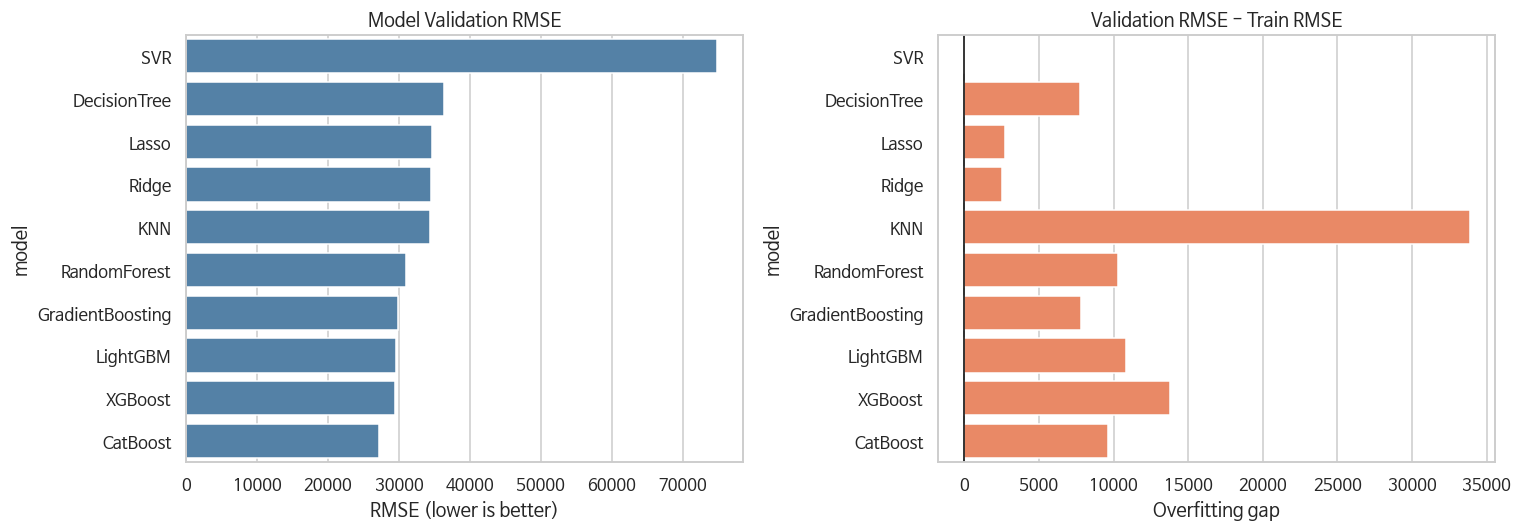

In [19]:
# ==============================================================================
# [1] 시각화를 위한 캔버스(Figure) 및 서브플롯(Axes) 구조 생성
# ==============================================================================
# 1행 2열 크기의 다중 그래프 구성을 정의하고, 가로 14인치, 세로 5인치로 전체 크기를 지정합니다.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==============================================================================
# [2] 시각화용 데이터 정렬
# ==============================================================================
# 바차트에서 성적이 좋은 모델(RMSE가 낮은 모델)이 맨 위에 오도록 차트를 그리기 위해,
# 데이터를 미리 'valid_rmse' 기준 내림차순(ascending=False)으로 정렬합니다.
plot_df = leaderboard.sort_values('valid_rmse', ascending=False)

# ==============================================================================
# [3] 왼쪽 그래프 (axes[0]): 모델별 검증 세트 RMSE 비교
# ==============================================================================
# x축에는 검증 RMSE 값, y축에는 모델명을 지정하여 가로 바차트(Horizontal Barplot)를 그립니다.
# - color='steelblue': 신뢰감을 주는 차분한 파란색 계열로 막대 색상 지정
sns.barplot(data=plot_df, x='valid_rmse', y='model', ax=axes[0], color='steelblue')

# 왼쪽 그래프의 제목 및 x축 라벨 설정
axes[0].set_title('Model Validation RMSE')
axes[0].set_xlabel('RMSE (lower is better)')  # 오차 지표이므로 낮을수록 우수함을 명시

# ==============================================================================
# [4] 오른쪽 그래프 (axes[1]): 모델별 과적합 격차(Overfitting Gap) 비교
# ==============================================================================
# x축에는 검증 RMSE와 훈련 RMSE의 차이(overfit_gap), y축에는 모델명을 지정합니다.
# - color='coral': 과적합 위험도를 직관적으로 인지할 수 있도록 다소 강렬한 코랄(오렌지/레드) 색상 지정
sns.barplot(data=plot_df, x='overfit_gap', y='model', ax=axes[1], color='coral')

# 과적합 여부의 기준점인 '0' 위치에 검은색 세로 점선(또는 실선)을 추가하여 시각적 기준을 제공합니다.
axes[1].axvline(0, color='black', linewidth=1)

# 오른쪽 그래프의 제목 및 x축 라벨 설정
axes[1].set_title('Validation RMSE - Train RMSE')
axes[1].set_xlabel('Overfitting gap')

# ==============================================================================
# [5] 그래프 레이아웃 최적화 및 화면 출력
# ==============================================================================
# 서브플롯 간의 간격이나 축 라벨이 서로 겹치지 않도록 여백을 자동으로 조정합니다.
plt.tight_layout()

# 완성된 서브플롯들을 화면에 렌더링합니다.
plt.show()

### 7-1. 성능 vs 학습시간 사분면

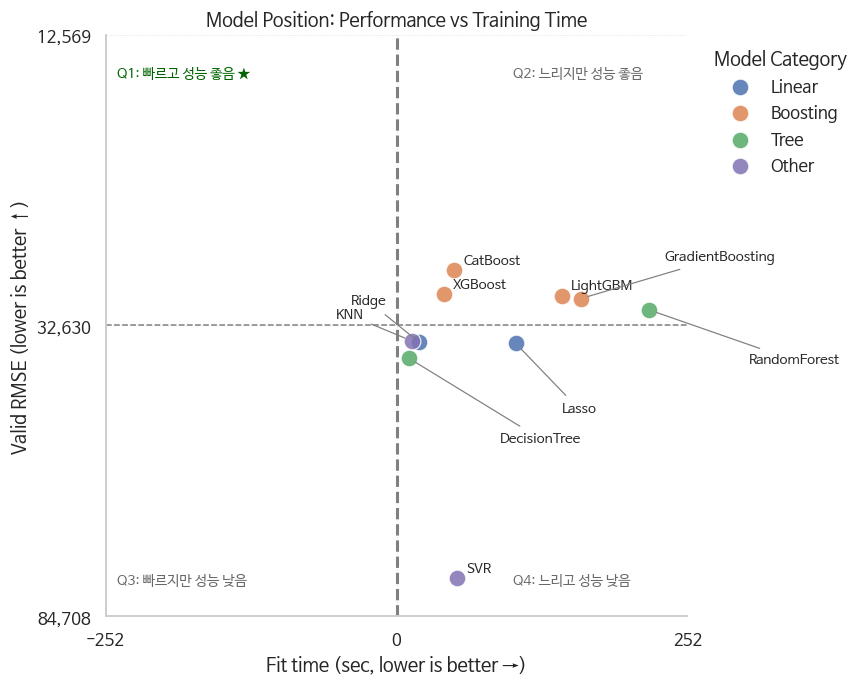

,model,category,fit_time_sec,valid_rmse,overfit_gap
8,DecisionTree,Tree,10.519,36312.793,7758.837
5,KNN,Other,13.326,34331.177,33873.791
6,Ridge,Linear,19.804,34493.765,2508.549
1,XGBoost,Boosting,40.755,29434.145,13788.634
0,CatBoost,Boosting,49.625,27243.592,9625.077
9,SVR,Other,52.649,74796.889,-53.908
7,Lasso,Linear,103.129,34612.859,2754.682
2,LightGBM,Boosting,142.713,29578.517,10830.758
3,GradientBoosting,Boosting,159.111,29883.174,7828.515
4,RandomForest,Tree,218.715,31012.252,10297.306


In [20]:
# ==============================================================================
# [1] 데이터 복사 및 모델별 계열(Category) 매핑
# ==============================================================================
# 기존 리더보드 데이터를 기반으로 사분면 시각화용 데이터프레임 생성
quad_df = leaderboard.copy()

# 10개 알고리즘을 성격에 맞는 범주(카테고리)로 묶어주기 위한 매핑 딕셔너리
model_category = {
    'Ridge': 'Linear',
    'Lasso': 'Linear',
    'CatBoost': 'Boosting',
    'XGBoost': 'Boosting',
    'GradientBoosting': 'Boosting',
    'LightGBM': 'Boosting',
    'DecisionTree': 'Tree',
    'RandomForest': 'Tree',
    'KNN': 'Other',
    'SVR': 'Other',
}
# 정의된 카테고리를 적용하고, 누락된 모델이 있다면 안전하게 'Other'로 채움
quad_df['category'] = quad_df['model'].map(model_category).fillna('Other')

# ==============================================================================
# [2] 시각화 스타일링 (카테고리별 색상 및 라벨 오프셋) 정의
# ==============================================================================
# 차트의 가독성을 높이기 위해 그룹별 고유 색상(Hex Code) 지정
category_colors = {
    'Linear': '#4C72B0',    # 차분한 파란색
    'Boosting': '#DD8452',  # 직관적인 오렌지색
    'Tree': '#55A868',      # 자연스러운 초록색
    'Other': '#8172B2',     # 보라색
}

# 텍스트 라벨이 서로 겹치거나 마커를 가리지 않도록 모델별 커스텀 텍스트 위치(오프셋 단위: pt) 설정
# (x_offset, y_offset) 형태로 지정
label_offsets = {
    'Ridge': (-45, 25),
    'Lasso': (30, -45),
    'KNN': (-50, 15),
    'DecisionTree': (60, -55),
    'GradientBoosting': (55, 25),
    'RandomForest': (65, -35),
}
default_offset = (6, 4) # 오프셋 수동 조정 리스트에 없는 모델들의 기본 여백

# ==============================================================================
# [3] 사분면 경계 및 축 범위 자동 동적 계산
# ==============================================================================
# 1. Y축(RMSE): 편차가 큰 RMSE의 스케일을 맞추기 위해 로그(log10) 공간에서 중앙값 계산
log_y = np.log10(quad_df['valid_rmse'])
log_y_med = log_y.median()
y_med = 10 ** log_y_med # 원본 스케일로 복원된 Y축 중앙값 (사분면 가로 지지선 기준)

# 2. X축 범위: 최대 학습 시간의 115% 수준을 기준으로 양방향(대칭) 경계 설정
x_max_abs = quad_df['fit_time_sec'].max() * 1.15
x_lo, x_hi = -x_max_abs, x_max_abs

# 3. Y축 범위: 로그 공간에서의 최대 편차의 115% 수준으로 상하 경계 확보
log_half = max(log_y_med - log_y.min(), log_y.max() - log_y_med) * 1.15
y_lo, y_hi = 10 ** (log_y_med - log_half), 10 ** (log_y_med + log_half)

# ==============================================================================
# [4] 산점도(Scatter) 플로팅 및 카테고리별 마커 생성
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# 각 카테고리별 데이터를 순회하며 산점도를 덧그림 (범례를 깔끔하게 분리하기 위함)
for cat, color in category_colors.items():
    sub = quad_df[quad_df['category'] == cat]
    if sub.empty:
        continue
    ax.scatter(
        sub['fit_time_sec'],
        sub['valid_rmse'],
        s=120,                   # 마커 크기 확대로 가시성 확보
        alpha=0.85,              # 약간의 투명도로 겹침 현상 완화
        c=color,
        edgecolors='white',      # 테두리를 흰색으로 주어 깔끔하게 구분
        linewidths=0.8,
        label=cat,
    )

# ==============================================================================
# [5] 모델명 어노테이션(Annotation/텍스트 라벨) 배치
# ==============================================================================
for _, row in quad_df.iterrows():
    offset = label_offsets.get(row['model'], default_offset)

    # 1. 수동 조정한 지시선 모델: 화살표(지시선)와 함께 텍스트 출력
    if row['model'] in label_offsets:
        ax.annotate(
            row['model'],
            xy=(row['fit_time_sec'], row['valid_rmse']), # 화살표가 가리킬 좌표 (실제 데이터 위치)
            xytext=offset,                                # 텍스트가 위치할 상대적 오프셋
            textcoords='offset points',
            fontsize=9,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, shrinkA=3, shrinkB=5), # 얇은 회색 선 설정
        )
    # 2. 기본 오프셋 모델: 지시선 없이 마커 근처에 바로 텍스트 출력
    else:
        ax.annotate(
            row['model'],
            xy=(row['fit_time_sec'], row['valid_rmse']),
            xytext=offset,
            textcoords='offset points',
            fontsize=9,
        )

# ==============================================================================
# [6] 축 제어 및 고급 스타일링
# ==============================================================================
ax.set_yscale('log')      # Y축을 로그 스케일로 지정
ax.invert_yaxis()         # Y축 뒤집기: 오차가 '낮을수록' 좋은 모델이므로 위로 갈수록 좋은 성적이 되도록 설정
ax.minorticks_off()       # 로그 스케일 특유의 촘촘한 마이너 틱(보조 눈금) 제거로 시각적 피로 감소

ax.set_xlim(x_lo, x_hi)   # 계산한 X축 범위 지정
ax.set_ylim(y_hi, y_lo)   # 계산한 Y축 범위 지정 (뒤집힌 상태 반영)
ax.set_box_aspect(1)      # 그래프 영역을 정사각형(1:1 비율)으로 강제 고정

# 사분면 분할 가이드 선 추가
ax.axvline(0, color='gray', linestyle='--', linewidth=2)      # 세로 기준선 (학습시간 0 기준)
ax.axhline(y_med, color='gray', linestyle='--', linewidth=1)  # 가로 기준선 (성능 중앙값 기준)

# 격자(Grid) 및 테두리(Spine) 정리
ax.grid(True, which='major', linestyle='--', linewidth=0.4, color='lightgray', alpha=0.6)
ax.set_axisbelow(True)    # 그리드 선이 데이터 마커 뒤로 숨도록 레이어 순서 지정
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False) # 우측과 상단 외곽 테두리 선 제거

# ==============================================================================
# [7] 축 틱(Tick) 라벨 및 이름 재정리
# ==============================================================================
# 최소값, 0, 최대값 3개의 주요 포인트만 지정하여 복잡함을 줄임
ax.set_xticks([x_lo, 0, x_hi])
ax.set_xticklabels([f'{x_lo:.0f}', '0', f'{x_hi:.0f}'])

ax.set_yticks([y_hi, y_med, y_lo])
ax.set_yticklabels([f'{y_hi:,.0f}', f'{y_med:,.0f}', f'{y_lo:,.0f}']) # 천단위 쉼표 포맷 반영

# 축 정보 및 타이틀 맵핑
ax.set_xlabel('Fit time (sec, lower is better →)')
ax.set_ylabel('Valid RMSE (lower is better ↑)')
ax.set_title('Model Position: Performance vs Training Time')

# ==============================================================================
# [8] 각 사분면 영역별 가이드 텍스트 삽입
# ==============================================================================
ax.text(x_lo + 0.02 * (x_hi - x_lo), y_lo * 1.15, 'Q1: 빠르고 성능 좋음 ★', fontsize=9, color='darkgreen')
ax.text(x_hi - 0.30 * (x_hi - x_lo), y_lo * 1.15, 'Q2: 느리지만 성능 좋음', fontsize=9, color='dimgray')
ax.text(x_lo + 0.02 * (x_hi - x_lo), y_hi * 0.9, 'Q3: 빠르지만 성능 낮음', fontsize=9, color='dimgray')
ax.text(x_hi - 0.30 * (x_hi - x_lo), y_hi * 0.9, 'Q4: 느리고 성능 낮음', fontsize=9, color='dimgray')

# 범례(Legend) 설정: 외부 우측 상단 배치 및 테두리 제거로 모던하게 표현
ax.legend(title='Model Category', loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=False)

# 레이아웃 여백 자동 조절 및 출력
plt.tight_layout()
plt.show()

# ==============================================================================
# [9] 사분면 차트 보조용 요약 데이터프레임 출력
# ==============================================================================
# 분석가가 빠르게 숫자로 확인할 수 있게 소수점 셋째 자리까지 반올림하여 서머리 출력
quad_df.loc[:, ['model', 'category', 'fit_time_sec', 'valid_rmse', 'overfit_gap']].sort_values('fit_time_sec').round(3)

## 8. 단일 Best 모델 테스트 평가

In [21]:
# ==============================================================================
# [1] 리더보드 1위 최적 단일 모델 객체 추출
# ==============================================================================
# 사전에 valid_rmse 기준으로 오름차순 정렬된 리더보드의 맨 첫 번째 행(인덱스 0)에서 모델명 추출
best_single_name = leaderboard.loc[0, 'model']

# 전체 search_objects 딕셔너리에서 해당 모델의 서치 객체를 가져온 후,
# 교차 검증을 통해 최종 학습 완료된 최적의 파이프라인(전처리+모델)인 'best_estimator_'를 추출합니다.
best_single_model = search_objects[best_single_name].best_estimator_

# ==============================================================================
# [2] 테스트 데이터셋(Hold-out)을 활용한 최종 예측 수행
# ==============================================================================
# 완전히 격리해 두었던 X_test 데이터를 최적 모델 파이프라인에 입력하여 주택 가격 예측값 계산
# (이때 내부에 내장된 preprocessor 변환기도 자동으로 함께 동작합니다.)
y_pred_single = best_single_model.predict(X_test)

# ==============================================================================
# [3] 최종 테스트 메트릭(평가지표) 계산
# ==============================================================================
# 1. Test RMSE: 예측값과 실제 정답 사이의 평균 제곱 오차(MSE)에 루트를 씌운 값 (낮을수록 우수)
rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))

# 2. Test MAE: 예측값과 실제 정답 사이의 절대 오차들의 평균 (직관적인 주택 가격 오차 스케일 제공)
mae_single = mean_absolute_error(y_test, y_pred_single)

# 3. Test R² (결정계수): 모델이 데이터의 분산을 얼마나 잘 설명하는지 비율로 나타낸 지표 (1에 가까울수록 우수)
r2_single = r2_score(y_test, y_pred_single)

# ==============================================================================
# [4] 검증 및 평가 결과 시각적 출력
# ==============================================================================
print('Best single model:', best_single_name)
print('Best params:', search_objects[best_single_name].best_params_)

# 금액 단위 가독성을 위해 천단위 쉼표 포맷(:,.0f)을 적용하여 출력합니다.
print(f'Test RMSE: {rmse_single:,.0f}')
print(f'Test MAE : {mae_single:,.0f}')
# 결정계수는 소수점 넷째 자리까지 정밀하게 표현합니다.
print(f'Test R2  : {r2_single:.4f}')

Best single model: CatBoost
Best params: {'model__depth': 5, 'model__iterations': 263, 'model__l2_leaf_reg': np.float64(1.058040360169664), 'model__learning_rate': np.float64(0.04637121010589463), 'model__rsm': np.float64(0.6679487325593814), 'model__subsample': np.float64(0.793551837122835)}
Test RMSE: 29,394
Test MAE : 18,200
Test R2  : 0.8874


## 9. Stacking Regressor

상위 5개 튜닝 모델을 base learner로 사용하고, `Ridge`를 final estimator로 사용합니다.
`StackingRegressor` 내부 CV로 meta feature가 만들어지므로 검증 누수를 줄일 수 있습니다.


In [23]:
# ==============================================================================
# [1] 리더보드 상위 5개 최적 모델 추출 및 스태킹 기반(Base) 모델 등록
# ==============================================================================
import numpy as np
from sklearn.base import clone

def to_native(value):
    """numpy 스칼라(np.float64, np.int64 등)를 순수 파이썬 타입으로 변환.
    CatBoost가 clone() 시 identity 비교에서 실패하는 문제를 예방합니다."""
    if isinstance(value, np.generic):
        return value.item()
    return value

top_model_names = leaderboard.loc[:, 'model'].head(5).tolist()

stack_estimators = []
for name in top_model_names:
    base_estimator, _ = model_spaces[name]        # 튜닝 전, 깨끗한 원본 모델 객체

    # 매번 새 파이프라인을 구성 (기존 best_estimator_를 그대로 재사용하지 않음)
    fresh_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', clone(base_estimator)),
    ])

    # best_params_ 값 중 numpy 타입을 파이썬 기본 타입으로 정리
    best_params = search_objects[name].best_params_
    clean_params = {k: to_native(v) for k, v in best_params.items()}

    fresh_pipe.set_params(**clean_params)          # 'model__xxx' 형태 키 그대로 사용 가능
    stack_estimators.append((name, fresh_pipe))

print('Stacking에 사용할 모델:', [name for name, _ in stack_estimators])

# ==============================================================================
# [2] StackingRegressor 객체 정의 및 빌드
# ==============================================================================
stacking_model = StackingRegressor(
    estimators=stack_estimators,         # 1단계: 개별 예측값을 생성할 기반(Base) 모델 목록
    final_estimator=Ridge(alpha=10.0),   # 2단계: 기반 모델들의 예측값을 인풋으로 받아 최종 정답을 도출할 메타(Meta) 모델
    cv=cv,                               # 메타 모델 학습용 데이터(Out-of-Fold 예측값)를 만들 때 사용할 5-Fold 객체
    n_jobs=-1,                           # 모든 CPU 코어를 활용하여 내부 기반 모델 학습 및 교차 검증을 병렬 처리
    passthrough=False,                   # True 설정 시 원본 피처(X)를 메타 모델에 같이 넘겨주지만, False로 지정하여 오직 기반 모델들의 예측값만 사용하도록 제한
)

# ==============================================================================
# [3] 스태킹 모델 학습 및 최종 테스트 데이터셋 예측
# ==============================================================================
# 1단계 모델들의 내부 OOF(Out-of-Fold) 예측 수행 후, 이를 모아 2단계 메타 모델까지 순차 학습 진행
stacking_model.fit(X_train, y_train)

# 완전히 격리된 테스트 세트(X_test)에 대한 최종 앙상블 예측값 산출
y_pred_stack = stacking_model.predict(X_test)

# ==============================================================================
# [4] 스태킹 앙상블 최종 성능 메트릭 평가
# ==============================================================================
# 1. Test RMSE: 실제 정답과 스태킹 앙상블 예측값 간의 루트 평균 제곱 오차 계산
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))

# 2. Test MAE: 실제 정답과 스태킹 앙상블 예측값 간의 평균 절대 오차 계산
mae_stack = mean_absolute_error(y_test, y_pred_stack)

# 3. Test R²: 스태킹 앙상블 모델의 최종 분산 설명력(결정계수) 평가
r2_stack = r2_score(y_test, y_pred_stack)

# ==============================================================================
# [5] 최종 스태킹 결과 시각적 출력
# ==============================================================================
print('Stacking base models:', top_model_names)

# 금액 단위 가독성을 위해 천단위 쉼표 포맷(:,.0f)을 적용하여 출력합니다.
print(f'Stacking Test RMSE: {rmse_stack:,.0f}')
print(f'Stacking Test MAE : {mae_stack:,.0f}')
# 결정계수는 소수점 넷째 자리까지 정밀하게 표현합니다.
print(f'Stacking Test R2  : {r2_stack:.4f}')

Stacking에 사용할 모델: ['CatBoost', 'XGBoost', 'LightGBM', 'GradientBoosting', 'RandomForest']
Stacking base models: ['CatBoost', 'XGBoost', 'LightGBM', 'GradientBoosting', 'RandomForest']
Stacking Test RMSE: 30,723
Stacking Test MAE : 18,561
Stacking Test R2  : 0.8769


## 10. 단일 모델 vs Stacking 비교

,method,test_rmse,test_mae,test_r2
0,Best Single (CatBoost),29394.135,18199.625,0.887
1,Stacking Top5,30723.059,18560.640,0.877


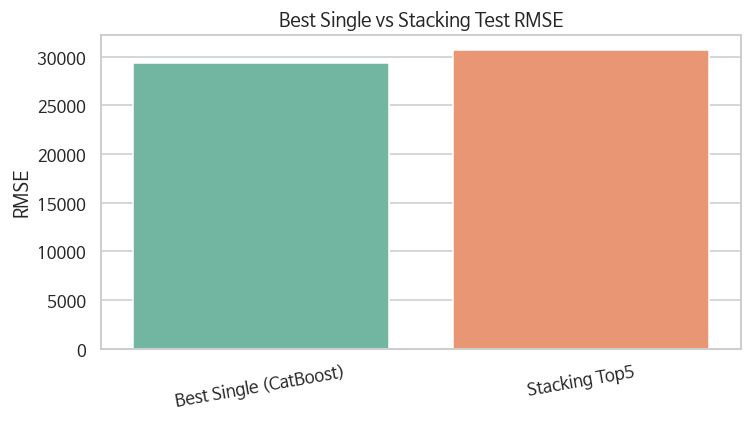

In [24]:
# ==============================================================================
# [1] 단일 최적 모델 vs 스태킹 앙상블 최종 성능 비교 데이터프레임 생성
# ==============================================================================
final_compare = pd.DataFrame({
    # 비교 대상 방법론 명칭 (단일 모델 이름 동적 반영)
    'method': [f'Best Single ({best_single_name})', 'Stacking Top5'],

    # 앞서 홀드아웃 테스트 세트(X_test)에서 계산된 3대 평가지표 리스트 매핑
    'test_rmse': [rmse_single, rmse_stack],
    'test_mae': [mae_single, mae_stack],
    'test_r2': [r2_single, r2_stack],
})

# 소수점 셋째 자리까지 반올림(.round(3))하여 요약 테이블을 주피터 노트북에 렌더링
display(final_compare.round(3))

# ==============================================================================
# [2] Test RMSE 기준 최종 가성비 및 성능 비교 시각화
# ==============================================================================
# 가로 7인치, 세로 4인치의 컴팩트한 사이즈로 단일 그래프 서브플롯 생성
fig, ax = plt.subplots(figsize=(7, 4))

# x축은 비교 방법론, y축은 에러 지표인 test_rmse를 지정하여 바차트 플로팅
# - palette='Set2': matplotlib/seaborn 제공 파스텔 톤의 깔끔한 색상 조합 적용
sns.barplot(data=final_compare, x='method', y='test_rmse', ax=ax, palette='Set2')

# 그래프 타이틀 및 축 정보 설정
ax.set_title('Best Single vs Stacking Test RMSE')
ax.set_xlabel('')            # x축 라벨은 범주명 자체가 명확하므로 생략 처리
ax.set_ylabel('RMSE')        # y축에 에러 지표 이름 명시

# x축에 표시되는 모델명이 길어져 텍스트가 겹치는 현상을 방지하기 위해 글자를 10도 살짝 회전
ax.tick_params(axis='x', rotation=10)

# ==============================================================================
# [3] 여백 조정 및 그래프 최종 화면 출력
# ==============================================================================
# 플롯 외곽 텍스트나 레이아웃이 잘리지 않도록 타이트하게 여백을 자동 조정
plt.tight_layout()

## 11. SHAP 해석 (최종 모델)

튜닝된 **Best Single 모델**에 대해 SHAP으로 변수 기여도를 확인합니다.

1. `preprocessor`로 변환된 학습 행렬을 만듭니다.
2. 트리 기반 모델이면 `shap.TreeExplainer`를 사용합니다.
3. 그 외 모델은 `shap.Explainer`로 대체합니다.


In [25]:
# ==============================================================================
# [1] 최적 파이프라인에서 모델 및 전처리 데이터 추출
# ==============================================================================
# 해석 대상이 될 최적의 단일 모델 파이프라인 지정
explain_pipe = best_single_model

# 파이프라인 내부의 마지막 스텝인 최종 알고리즘(모델) 객체 분리
preprocessed_model = explain_pipe.named_steps['model']

# 파이프라인의 전처리(preprocessor) 단계만 선제 적용하여 훈련 데이터를 2진화/스케일링 변환
transformed_train = explain_pipe.named_steps['preprocessor'].transform(X_train)

# 원-핫 인코딩 등으로 확장된 최종 변환 피처들의 전체 이름(텍스트) 배열 추출
feature_names = explain_pipe.named_steps['preprocessor'].get_feature_names_out()

# ==============================================================================
# [2] SHAP 연산 최적화를 위한 데이터 샘플링 (Computational Budgeting)
# ==============================================================================
# 고차원 데이터나 대량의 데이터에서 SHAP 속도를 높이기 위해 독립된 Generator 생성
rng = np.random.default_rng(RANDOM_STATE)

# 전체 데이터가 300개보다 적을 수 있으므로 안전하게 최댓값 유도 (최대 300개 픽스)
sample_size = min(300, transformed_train.shape[0])

# 복원 추출을 허용하지 않고(replace=False) 무작위로 인덱스 추출
sample_idx = rng.choice(transformed_train.shape[0], size=sample_size, replace=False)

# SHAP 설명 모델에 주입할 최종 경량화 데이터셋 구성
X_shap = transformed_train[sample_idx]

# ==============================================================================
# [3] 모델 유형(Tree vs Non-Tree)에 따른 Explainer 동적 할당 및 SHAP 계산
# ==============================================================================
# 고속 연산 전용 'TreeExplainer'를 적용할 트리 기반 알고리즘 유형 정의 (튜플 형태)
tree_types = (
    DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor,
    XGBRegressor, LGBMRegressor, CatBoostRegressor,
)

# 현재 모델이 위에 정의한 트리 계열 인스턴스에 해당하는지 조건문 검증
if isinstance(preprocessed_model, tree_types):
    # 1. 트리 계열: 고속 전용 TreeExplainer 가동 및 SHAP Matrix 산출
    explainer = shap.TreeExplainer(preprocessed_model)
    shap_values = explainer.shap_values(X_shap)
else:
    # 2. 비트리 계열 (Ridge, Lasso, KNN, SVR 등): 일반 범용 Explainer 커널 가동
    # - 예측 함수(.predict)와 배경 데이터를 기반으로 순열(Permutation) 방식 등의 연산 수행
    explainer = shap.Explainer(preprocessed_model.predict, X_shap)
    shap_values = explainer(X_shap).values # 객체 결과물에서 가치 배열만 래핑 추출

# ==============================================================================
# [4] SHAP 분석 준비 완료 및 정보 출력
# ==============================================================================
# 최종 연산이 수행된 데이터의 규격과 선택된 해석기 클래스 명칭 출력 확인
print('SHAP sample shape:', X_shap.shape)
print('Explainer type:', type(explainer).__name__)

SHAP sample shape: (300, 52)
Explainer type: TreeExplainer


### 차트 해석

- **y축**: SHAP 중요도 순으로 정렬된 피처 (위로 갈수록 예측에 미치는 영향력이 큼)
- **x축**: SHAP value — 해당 피처가 예측값(집값)을 얼마나 밀어올리거나(+) 끌어내렸는지(-)
- **점 색깔**: 그 피처의 실제 값 크기 (빨강=높음, 파랑=낮음)
- **점 하나 = 데이터 하나(집 한 채)**

- **`num__GrLivArea` (지상 생활면적)** — 가장 영향력이 큰 피처. 빨간 점(면적이 큼)이 오른쪽으로 넓게 퍼져있어 **면적이 클수록 집값을 크게 끌어올림**. 일부는 SHAP value가 +100,000까지도 감. 파란 점(면적 작음)은 반대로 음(-)의 영향.
- **`num__OverallQual` (전반적 품질)** — 두 번째로 중요. 역시 품질이 높을수록(빨강) 가격 상승 폭이 크고, 낮을수록(파랑) 하락 방향. 다만 GrLivArea보다는 상승 폭이 다소 완만함.
- **`num__TotalBsmtSF` (지하실 면적)** — 지하실이 넓을수록(빨강) 가격 상승, 좁거나 없으면(파랑) 하락 쪽에 몰려있음.
- **`num__YearBuilt`, `num__GarageCars`, `num__TotalBath`** — 신축일수록/차고가 많을수록/욕실 수가 많을수록 가격에 양(+)의 영향. 다만 영향 크기는 위 3개보다 작음.
- **`num__HouseAge`** — YearBuilt와 반대 방향으로 작동 (당연히 상관관계가 높은 피처). 오래된 집(빨강, age 큼)일수록 음(-)의 영향.
- **`cat__ExterQual_Gd` / `cat__ExterQual_TA`** — 외장재 품질 카테고리. `Gd`(Good)면 양의 영향, `TA`(Typical/Average)면 음의 영향 — 등급 자체가 가격에 반영되는 걸 보여줌.
- **`cat__Neighborhood_Crawfor`** — 특정 동네(Crawford) 더미변수. 빨간 점(해당 동네=1)들이 오른쪽에 몰려 있어 **이 동네에 속하면 가격이 상승하는 방향으로 작용**. 다만 데이터 포인트 수 자체가 적어 보임(집 개수가 많지 않은 동네일 가능성).
- **`cat__CentralAir_N`** — 중앙냉방이 없으면(`N`=1, 빨강) 가격이 하락하는 방향으로 작용 — 중앙냉방 유무가 가격에 꽤 명확하게 반영됨.
- **`num__FullBath`, `num__HalfBath`, `num__BsmtFullBath`** — 화장실 개수 관련 피처들. 각각 단독으로는 영향력이 작지만, 방향성은 일관되게 "개수 많을수록(빨강) 가격 상승".
- 상위 3개 피처(`GrLivArea`, `OverallQual`, `TotalBsmtSF`)가 **크기/면적/품질 계열**로, 이 셋이 전체 예측력의 상당 부분을 차지하는 구조.
- 색깔(빨강/파랑)과 SHAP 방향(오른쪽/왼쪽)이 대부분 **직관적으로 일치** — 즉 모델이 "이상하게" 학습된 게 아니라 상식적인 패턴(넓고 좋을수록 비쌈)을 잘 포착했다는 신호.
- `num__GrLivArea`는 꼬리 부분에 SHAP value가 +100,000 넘는 극단치가 몇 개 있는데, 이런 **초대형 평수 이상치**가 모델 예측에 큰 영향을 주고 있을 가능성이 있어 별도로 확인해볼 가치가 있어요.


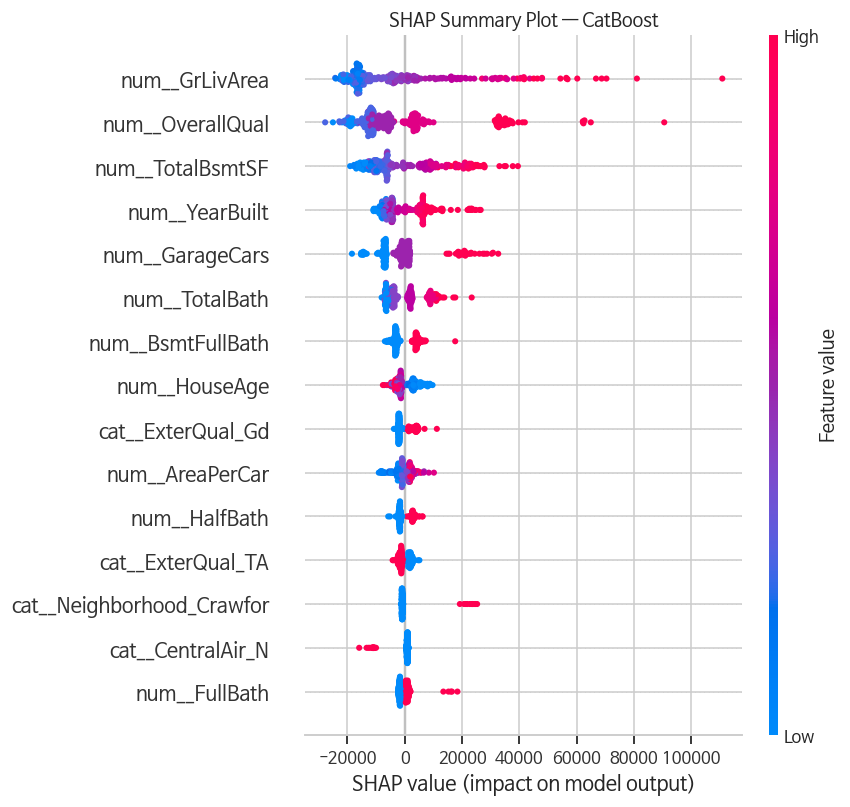

In [26]:
# ==============================================================================
# [1] SHAP Summary Plot 시각화 전용 도화지(Canvas) 생성
# ==============================================================================
# 그래프의 가시성을 확보하기 위해 가로 10인치, 세로 6인치 크기로 설정합니다.
plt.figure(figsize=(10, 6))

# ==============================================================================
# [2] SHAP 글로벌 요약 프로필(Summary Plot) 그리기
# ==============================================================================
# - shap_values : 각 샘플 및 피처별로 계산된 영향도(Shapley Value) 행렬
# - X_shap      : SHAP 계산에 사용되었던 실제 전처리 플래싱 데이터셋 (특성 값의 높고 낮음을 색상으로 표현)
# - feature_names : 수치형/범주형 변수가 통합 전처리되어 인코딩된 최종 컬럼명 배열
# - show=False  : matplotlib 내에서 타이틀 변경 등 추가적인 커스텀을 허용하기 위해 즉시 출력을 방지
# - max_display=15 : 시각적 복잡도를 줄이기 위해 영향도가 높은 상위 15개 변수만 필터링하여 출력
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False,
    max_display=15,
)

# ==============================================================================
# [3] 차트 타이틀 및 레이아웃 커스텀 후 최종 출력
# ==============================================================================
# 리더보드 1위 모델의 명칭을 동적으로 반영하여 차트의 제목을 부여합니다.
plt.title(f'SHAP Summary Plot — {best_single_name}')

# 텍스트나 축 라벨이 도화지 밖으로 밀려나 잘리는 현상을 자동으로 예방합니다.
plt.tight_layout()

# 완성된 SHAP 시각화 차트를 노트북 화면에 최종 렌더링합니다.
plt.show()

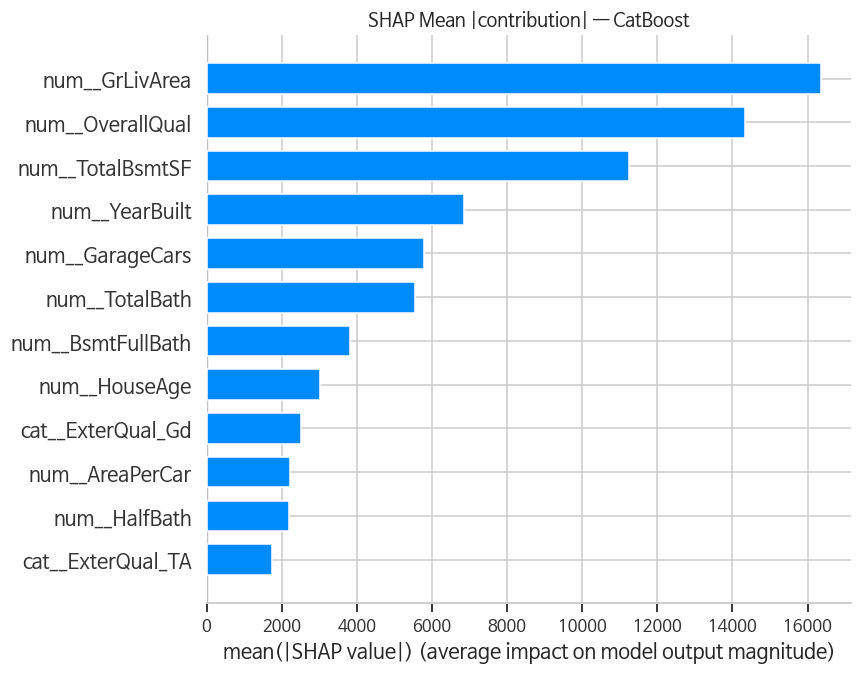

In [27]:
# ==============================================================================
# [1] SHAP 가로 바차트(Bar Plot) 캔버스 생성 및 플로팅
# ==============================================================================
# 가로 8인치, 세로 5인치 크기의 그래프 공간을 정의합니다.
plt.figure(figsize=(8, 5))

# shap 패키지의 summary_plot을 사용하여 각 변수의 평균 절대 SHAP 값을 그립니다.
shap.summary_plot(
    shap_values,                 # 모델 유형별로 계산된 SHAP 가치 배열/객체
    X_shap,                      # 전처리 및 샘플링이 완료된 입력 데이터 Matrix
    feature_names=feature_names, # 원-핫 인코딩 등이 반영된 최종 피처 이름 배열
    plot_type='bar',             # 중요도 비교에 특화된 'bar'(막대) 형태로 지정
    show=False,                  # 내장된 plt.show() 자동 호출을 막고, 아래 커스텀 타이틀 설정을 허용
    max_display=12,              # 영향력이 높은 상위 12개 피처만 선별하여 출력 (나머지는 자동으로 묶임)
)

# ==============================================================================
# [2] 그래프 타이틀 및 레이아웃 커스텀 설정
# ==============================================================================
# 리더보드 1위 모델의 이름을 제목에 동적으로 포함하여 어떤 모델의 해석인지 명시합니다.
plt.title(f'SHAP Mean |contribution| — {best_single_name}')

# 축 라벨이나 타이틀 텍스트가 캔버스 외곽으로 잘려 나가지 않도록 여백을 최적화합니다.
plt.tight_layout()

# 완성된 SHAP 중요도 차트를 화면에 최종 렌더링합니다.
plt.show()

## 12. Kaggle Test 예측 및 Submission

로컬 `train/test` 분리는 **모델 선택용**이었습니다.
Kaggle 제출을 위해 **전체 학습 데이터**로 Best Single 모델을 다시 학습한 뒤,
`datasets/kaggle_house_price/test.csv`에 예측합니다.

> 제출 파일 형식은 `sample_submission.csv`와 동일합니다 (`Id`, `SalePrice`).

In [29]:
from sklearn.base import clone
import numpy as np

def to_native(value):
    """numpy 스칼라(np.float64, np.int64 등)를 순수 파이썬 타입으로 변환.
    CatBoost가 clone() 시 identity 비교에서 실패하는 문제를 예방합니다."""
    if isinstance(value, np.generic):
        return value.item()
    return value

# ==============================================================================
# [1] 전체 학습 데이터셋(Full Dataset) 빌드 및 파생변수 반영
# ==============================================================================
X_full = add_house_features(X.copy())
y_full = y.copy()

# ==============================================================================
# [2] 최적 단일 모델 복제(Clone) 및 전체 데이터 기반 재학습(Retrain)
# ==============================================================================
# best_estimator_를 직접 clone하지 않고, model_spaces의 '깨끗한 원본 estimator'를 clone한 뒤
# best_params_ 값(numpy 타입 -> 파이썬 기본 타입 변환)을 다시 세팅합니다.
base_estimator, _ = model_spaces[best_single_name]

submission_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', clone(base_estimator)),
])

best_params = search_objects[best_single_name].best_params_
clean_params = {k: to_native(v) for k, v in best_params.items()}
submission_model.set_params(**clean_params)

# 쪼개지지 않은 전체 데이터(X_full, y_full)를 주입하여 최종 모델을 다시 학습시킵니다.
submission_model.fit(X_full, y_full)

# ==============================================================================
# [3] 캐글 테스트 데이터 로드 및 학습 세트와 동일한 파생변수 적용
# ==============================================================================
kaggle_test = pd.read_csv(DATA_DIR / 'test.csv')
X_kaggle = kaggle_test.loc[:, base_features].copy()
X_kaggle = add_house_features(X_kaggle)

# ==============================================================================
# [4] 최종 예측 수행 및 제출용 데이터프레임(Submission) 구성
# ==============================================================================
y_kaggle_pred = submission_model.predict(X_kaggle)

submission = pd.DataFrame({
    'Id': kaggle_test.loc[:, 'Id'],
    'SalePrice': y_kaggle_pred,
})

# ==============================================================================
# [5] CSV 파일 저장 및 최종 결과 검증 출력
# ==============================================================================
submission_path = 'final_submission.csv'
submission.to_csv(submission_path, index=False)

print('Best model for submission:', best_single_name)
print('Kaggle test rows:', len(submission))

submission.head()

Best model for submission: CatBoost
Kaggle test rows: 1459


,Id,SalePrice
0,1461,117105.869858
1,1462,148534.688262
2,1463,164075.246613
3,1464,170769.405601
4,1465,190812.338169


## 13. 정리

1. **train/test 분리 후** `X_train`에 파생변수를 만들고, 같은 함수를 `X_test`에 적용했습니다.
2. **sklearn 1.6.1** 스타일 `OneHotEncoder(sparse_output=False)` Pipeline을 사용했습니다.
3. 공식 문서의 regularization / tree complexity 파라미터를 참고해 **과적합을 억제하는 탐색 공간**을 설정했습니다.
4. 10개 모델을 **학습 시간 + CV 지표**로 비교하고, 사분면 scatter로 위치를 시각화했습니다.
5. 상위 5개를 Stacking하고, **SHAP**으로 최종 단일 모델을 해석했습니다.
6. **Kaggle test.csv**로 `submission.csv`를 생성했습니다.
7. 로컬 테스트 데이터는 마지막 단일 vs Stacking 비교에만 사용했습니다.
